# DS 592 Homework 5 — Programming Assignment

## Problem 3: Exp3 on Stochastic Bandits

**Performance note:** All algorithms are batch-vectorized — every simulation runs in parallel via NumPy. The only Python loop is over time steps (which is inherently sequential).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(592)

In [2]:
def exp3_adversarial_batch(n, K, eta, losses, S):
    """
    Run S simulations of Exp3 on an oblivious adversary IN PARALLEL.
    losses: (n, K) array.
    Returns: array of shape (S,) with final regret for each sim.
    """
    L_hat = np.zeros((K, S))          # cumulative estimated losses per arm per sim
    total_loss = np.zeros(S)          # learner's cumulative loss per sim

    for t in range(n):
        # softmax over arms for all sims at once: (K, S)
        logits = -eta * L_hat
        logits -= logits.max(axis=0, keepdims=True)
        w = np.exp(logits)
        p = w / w.sum(axis=0, keepdims=True)      # (K, S)

        # sample actions: for K=2 just compare uniform to p[0]
        u = np.random.rand(S)
        cum_p = np.cumsum(p, axis=0)               # (K, S)
        actions = (u >= cum_p[:-1]).sum(axis=0)     # (S,) ints in [0, K-1]

        # observed losses
        loss_t = losses[t, actions]                 # (S,)
        total_loss += loss_t

        # importance-weighted loss update: only the chosen arm gets updated
        p_chosen = p[actions, np.arange(S)]         # (S,)
        y_hat = loss_t / p_chosen                   # (S,)
        # scatter into L_hat
        np.add.at(L_hat, (actions, np.arange(S)), y_hat)

    best_arm_loss = np.min(losses.sum(axis=0))
    return total_loss - best_arm_loss


def exp3_stochastic_batch(mu, n, eta, S):
    """
    Run S simulations of Exp3 (loss-based, Eq 11.6) on a stochastic
    Bernoulli bandit IN PARALLEL.
    Returns: final expected regret (scalar, averaged over S sims).
    """
    K = len(mu)
    mu_arr = np.array(mu)
    mu_star = mu_arr.max()
    S_hat = np.zeros((K, S))# cumulative estimated rewards
    cum_regret = np.zeros(S)

    for t in range(n):
        logits = eta * S_hat
        logits -= logits.max(axis=0, keepdims=True)
        w = np.exp(logits)
        p = w / w.sum(axis=0, keepdims=True)       # (K, S)

        u = np.random.rand(S)
        cum_p = np.cumsum(p, axis=0)
        actions = (u >= cum_p[:-1]).sum(axis=0)     # (S,)

        # Bernoulli rewards for all sims
        rewards = (np.random.rand(S) < mu_arr[actions]).astype(float)  # (S,)

        # loss-based estimator (Eq 11.6): X_hat_i = 1 - 1(a=i)(1-X)/p_i
        # for unplayed arms: X_hat = 1, so S_hat += 1 for all arms
        S_hat += 1.0
        # correction for played arm: subtract 1 and add the actual estimator
        p_chosen = p[actions, np.arange(S)]
        x_hat_played = 1.0 - (1.0 - rewards) / p_chosen
        np.add.at(S_hat, (actions, np.arange(S)), x_hat_played - 1.0)

        cum_regret += mu_star - mu_arr[actions]

    return cum_regret.mean()


def ucb_batch(mu, n, S):
    """
    Run S simulations of asymptotically optimal UCB (Algorithm 6)
    on a Bernoulli bandit IN PARALLEL.
    Returns: final expected regret (scalar, averaged over S sims).
    """
    K = len(mu)
    mu_arr = np.array(mu)
    mu_star = mu_arr.max()
    N_i = np.zeros((K, S))
    Sum_i = np.zeros((K, S))
    cum_regret = np.zeros(S)

    for t in range(1, n + 1):
        if t <= K:
            actions = np.full(S, t - 1, dtype=int)
        else:
            f_t = 1.0 + t * (np.log(t)) ** 2
            mu_hat = Sum_i / N_i # (K, S)
            bonus = np.sqrt(0.5 * np.log(f_t) / N_i) # sigma^2=0.25 for Bernoulli
            ucb_vals = mu_hat + bonus # (K, S)
            actions = ucb_vals.argmax(axis=0) # (S,)

        rewards = (np.random.rand(S) < mu_arr[actions]).astype(float)
        np.add.at(N_i, (actions, np.arange(S)), 1)
        np.add.at(Sum_i, (actions, np.arange(S)), rewards)
        cum_regret += mu_star - mu_arr[actions]

    return cum_regret.mean()

---
# Problem 3: Exp3 on Stochastic Bandits

We compare UCB and Exp3 on a two-armed stochastic Bernoulli bandit with $\mu_1 = 0.5$ and $\mu_2 = \mu_1 + \Delta$ where $\Delta = 0.05$.

## Part (a): Regret of UCB and Exp3 as a function of horizon $n$

Using $\eta = \sqrt{2\log(K)/(nK)}$ for Exp3, $\mu_1 = 0.5$, $\mu_2 = 0.55$, $\Delta = 0.05$.

In [3]:
K = 2
Delta = 0.05
mu = [0.5, 0.5 + Delta]
S = 50

horizons = [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000]
ucb_final = []
exp3_final = []

for n_val in horizons:
    print(f"Running n = {n_val}...")
    ucb_final.append(ucb_batch(mu, n_val, S))
    eta_val = np.sqrt(2 * np.log(K) / (n_val * K))
    exp3_final.append(exp3_stochastic_batch(mu, n_val, eta_val, S))

print("Done.")

Running n = 500...
Running n = 1000...
Running n = 2000...
Running n = 5000...
Running n = 10000...
Running n = 20000...
Running n = 50000...
Running n = 100000...
Done.


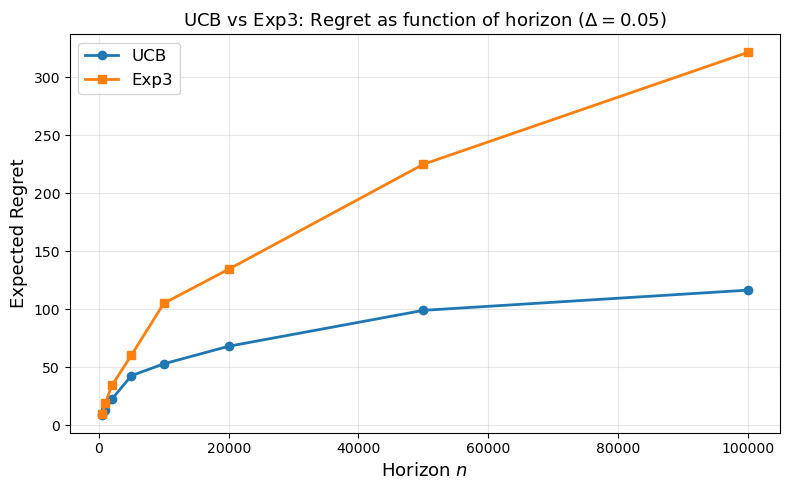


UCB achieves logarithmic regret O(log(n)/Delta) while Exp3 achieves O(sqrt(nK*log(K))).


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(horizons, ucb_final, 'o-', label='UCB', linewidth=2)
ax.plot(horizons, exp3_final, 's-', label='Exp3', linewidth=2)
ax.set_xlabel('Horizon $n$', fontsize=13)
ax.set_ylabel('Expected Regret', fontsize=13)
ax.set_title(f'UCB vs Exp3: Regret as function of horizon ($\\Delta = {Delta}$)', fontsize=13)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('problem3a_regret_vs_horizon.png', dpi=150)
plt.show()

print("\nUCB achieves logarithmic regret O(log(n)/Delta) while Exp3 achieves O(sqrt(nK*log(K))).")

## Part (b): Regret as a function of the learning rate $\eta$ (fixed $n = 10^5$)

Fix $n = 10^5$ and plot the expected regret of Exp3 as a function of the learning rate $\eta$. Should look like Fig. 2 in the HW.

In [5]:
n_fixed = 100000
K = 2
Delta = 0.05
mu = [0.5, 0.5 + Delta]
S = 30

etas = np.concatenate([
    np.linspace(0.001, 0.01, 10),
    np.linspace(0.012, 0.03, 10),
    np.linspace(0.035, 0.06, 6),
    np.linspace(0.07, 0.12, 6)
])

exp3_regrets_by_eta = []
for i, eta_val in enumerate(etas):
    r = exp3_stochastic_batch(mu, n_fixed, eta_val, S)
    exp3_regrets_by_eta.append(r)
    if (i + 1) % 8 == 0:
        print(f"  eta = {eta_val:.4f} -> avg regret = {r:.1f}  ({i+1}/{len(etas)})")

print("Done.")

  eta = 0.0080 -> avg regret = 234.7  (8/32)
  eta = 0.0220 -> avg regret = 384.3  (16/32)
  eta = 0.0500 -> avg regret = 746.0  (24/32)
  eta = 0.1200 -> avg regret = 1322.1  (32/32)
Done.


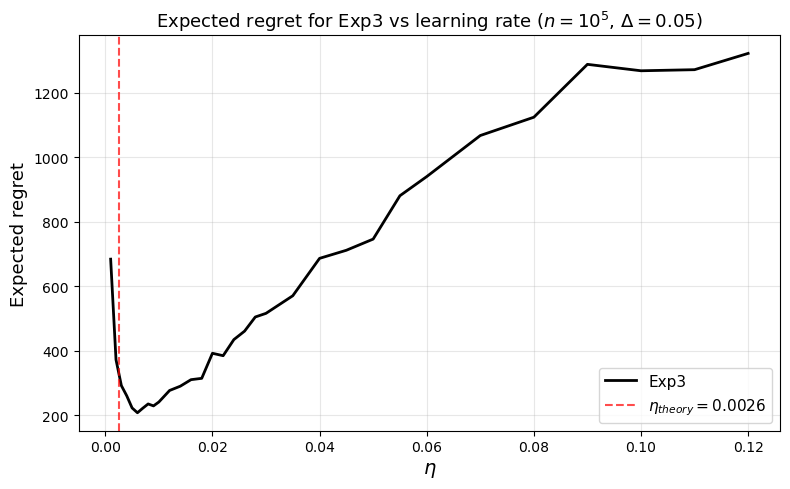


Theory-prescribed eta = sqrt(2*log(K)/(n*K)) = 0.00263
Empirically best eta (from our sweep) = 0.00600
Min regret achieved = 207.3


In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(etas, exp3_regrets_by_eta, 'k-', linewidth=2, label='Exp3')

eta_theory = np.sqrt(2 * np.log(K) / (n_fixed * K))
ax.axvline(x=eta_theory, color='red', linestyle='--', alpha=0.7, label=f'$\\eta_{{theory}} = {eta_theory:.4f}$')

ax.set_xlabel(r'$\eta$', fontsize=14)
ax.set_ylabel('Expected regret', fontsize=13)
ax.set_title(f'Expected regret for Exp3 vs learning rate ($n = 10^5$, $\\Delta = {Delta}$)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('problem3b_regret_vs_eta.png', dpi=150)
plt.show()

print(f"\nTheory-prescribed eta = sqrt(2*log(K)/(n*K)) = {eta_theory:.5f}")
print(f"Empirically best eta (from our sweep) = {etas[np.argmin(exp3_regrets_by_eta)]:.5f}")
print(f"Min regret achieved = {np.min(exp3_regrets_by_eta):.1f}")

## Part (c): How does the shape change as $\Delta$ changes?

We repeat the sweep over $\eta$ for several values of $\Delta$.

In [ ]:
n_fixed = 100000
K = 2
S = 20

deltas = [0.01, 0.05, 0.1, 0.2, 0.3]
etas_sweep = np.concatenate([
    np.linspace(0.001, 0.01, 8),
    np.linspace(0.015, 0.05, 8),
    np.linspace(0.06, 0.12, 7),
    np.linspace(0.15, 0.3, 5)
])

results_by_delta = {}
for Delta in deltas:
    print(f"Running Delta = {Delta}...")
    mu = [0.5, 0.5 + Delta]
    regrets_for_delta = []
    for eta_val in etas_sweep:
        r = exp3_stochastic_batch(mu, n_fixed, eta_val, S)
        regrets_for_delta.append(r)
    results_by_delta[Delta] = regrets_for_delta

print("Done.")

Running Delta = 0.01...


In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
for Delta in deltas:
    ax.plot(etas_sweep, results_by_delta[Delta], '-o', markersize=3, linewidth=1.5, label=f'$\\Delta = {Delta}$')

ax.set_xlabel(r'$\eta$', fontsize=14)
ax.set_ylabel('Expected regret', fontsize=13)
ax.set_title(f'Exp3 regret vs learning rate for different $\\Delta$ ($n = 10^5$)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('problem3c_regret_vs_eta_deltas.png', dpi=150)
plt.show()

print("\nObservation: As Delta increases, the optimal eta shifts to the right (larger learning")
print("rates are better for larger gaps). The curve also becomes more U-shaped: too-small eta")
print("leads to insufficient exploitation (high regret from exploring too much), while too-large")
print("eta leads to excessive concentration on the wrong arm before enough data is gathered.")
print("For larger Delta, the 'dip' in regret is deeper and the optimal regret is smaller.")

## Part (d): Empirically optimal $\eta$ for worst-case regret over all $\Delta$

For each $\eta$, compute the worst-case (maximum) regret over all $\Delta$ values, then find the $\eta$ that minimizes this worst-case.

In [ ]:
worst_case_regret = []
for j in range(len(etas_sweep)):
    max_regret = max(results_by_delta[Delta][j] for Delta in deltas)
    worst_case_regret.append(max_regret)

best_idx = np.argmin(worst_case_regret)
eta_empirical_best = etas_sweep[best_idx]
eta_theory = np.sqrt(2 * np.log(K) / (n_fixed * K))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(etas_sweep, worst_case_regret, 'k-o', markersize=4, linewidth=2, label='Worst-case regret over $\\Delta$')
ax.axvline(x=eta_empirical_best, color='blue', linestyle='--', alpha=0.7,
           label=f'Empirical best $\\eta = {eta_empirical_best:.4f}$')
ax.axvline(x=eta_theory, color='red', linestyle='--', alpha=0.7,
           label=f'Theory $\\eta = {eta_theory:.4f}$')

ax.set_xlabel(r'$\eta$', fontsize=14)
ax.set_ylabel('Worst-case expected regret', fontsize=13)
ax.set_title(f'Minimax $\\eta$: worst-case regret over $\\Delta$ ($n = 10^5$)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('problem3d_minimax_eta.png', dpi=150)
plt.show()

print(f"\nTheory-prescribed eta = sqrt(2*log(K)/(n*K)) = {eta_theory:.5f}")
print(f"Empirically best minimax eta = {eta_empirical_best:.5f}")
print(f"Worst-case regret at empirical best = {worst_case_regret[best_idx]:.1f}")

## Part (e): Conclusions — Tell an interesting story

Below we summarize the key takeaways from all the experiments.

In [ ]:
story = """
=== CONCLUSIONS ===

1. UCB vs Exp3 (Part a):
   UCB gets O(log n / Delta) regret; Exp3 gets O(sqrt(nK log K)).
   Exp3 pays a steep price for not exploiting the stochastic structure.

2. Learning rate sensitivity (Part b):
   Too small eta -> explores too much. Too large eta -> locks onto the wrong arm.
   The theory value eta = sqrt(2 log(K)/(nK)) is near-optimal but tuned for adversarial worst case.

3. Effect of Delta (Part c):
   Larger Delta -> easier problem, lower optimal regret, wider range of good eta.
   Optimal eta increases with Delta since larger gaps tolerate more aggressive exploitation.

4. Minimax eta (Part d):
   The empirical minimax eta is close to the theory value.
   Modest gains from tuning beyond the default, since the theory rate is already near-optimal.

5. The big picture:
   Exp3 is robust (works against adversaries) but wasteful on stochastic data.
   UCB is optimal for stochastic settings but fragile against adversaries.
   This robustness-vs-performance tradeoff is a central theme in bandit theory?
"""
print(story)